In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
!pip install -q gdown

In [4]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="Yuehao/celeba",
    repo_type="dataset",
    local_dir="/content/celeba"
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

'/content/celeba'

In [5]:
import os

print(os.listdir("/content/celeba"))

['list_eval_partition.txt', 'identity_CelebA.txt', 'list_landmarks_align_celeba.txt', 'list_bbox_celeba.txt', '.gitattributes', 'README.md', 'img_align_celeba.zip', '.cache', 'list_attr_celeba.txt']


In [29]:
import zipfile
import os

zip_path = "/content/celeba/img_align_celeba.zip"

print("File exists:", os.path.exists(zip_path))
print("File size:", round(os.path.getsize(zip_path) / (1024**3), 2), "GB")
print("Valid ZIP:", zipfile.is_zipfile(zip_path))

File exists: True
File size: 1.34 GB
Valid ZIP: True


In [30]:
import zipfile
import os

zip_path = "/content/celeba/img_align_celeba.zip"
extract_dir = "/content/celeba"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extraction complete!")

Extraction complete!


In [31]:
import os

image_dir = "/content/celeba/img_align_celeba"

print("Folder exists:", os.path.exists(image_dir))
print("Number of images:", len(os.listdir(image_dir)))
print("First 10 images:", sorted(os.listdir(image_dir))[:10])

Folder exists: True
Number of images: 202599
First 10 images: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg', '000006.jpg', '000007.jpg', '000008.jpg', '000009.jpg', '000010.jpg']


In [32]:
import torch
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

In [33]:
from inspect import trace
# Images load => transform

class ImageProcessor:
  def __init__(self, root_dir_path, transformations=None):
    self.root_dir_path = root_dir_path
    self.transformations = transformations

    #list of paths for all images
    self.all_img_paths = [
    os.path.join(root_dir_path, img)
    for img in os.listdir(root_dir_path)
    ]
  def __len__(self):
    return len(self.all_img_paths)

  def __getitem__(self,idx):
    img_path = self.all_img_paths[idx]
    img = Image.open(img_path).convert("RGB")

    if self.transformations:
      img = self.transformations(img)
    return img




In [34]:
root_dir_path = "/content/celeba/img_align_celeba"
transformations = transforms.Compose([
    transforms.CenterCrop(178), #178x218 => 178x178
    transforms.Resize(64), # 64x64
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5)) #[-1, 1]
])

In [35]:
dataset = ImageProcessor(root_dir_path, transformations)
print(f"loaded {len(dataset)} images")

loaded 202599 images


In [36]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)


In [37]:
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [38]:
## Generator Network
class Generator(nn.Module):
  def __init__(self, z_dim=100, img_channels=3):
    super(Generator, self).__init__()

    self.model = nn.Sequential(
        nn.Linear(z_dim, 256),
        nn.ReLU(),

        nn.Linear(256, 512),
        nn.ReLU(),

        nn.Linear(512, 1024),
        nn.ReLU(),

        nn.Linear(1024,64*64*img_channels),
        nn.Tanh() #[-1,1]

    )
  def forward(self, z):
    img = self.model(z)
    img = img.view(img.size(0), 3, 64, 64)
    return img



In [39]:
## Discriminator Network
class Discriminator(nn.Module):
  def __init__(self, img_channels=3):
    super(Discriminator, self).__init__()

    self.model = nn.Sequential(
        nn.Flatten(), #4D to 1D

        nn.Linear(img_channels*64*64, 1024),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Linear(1024, 512),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Linear(512, 256),
        nn.LeakyReLU(0.2, inplace=True),

        nn.Linear(256, 1),
        nn.Sigmoid() # probability of being fake

    )

  def forward(self, img):
    return self.model(img)



In [41]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

GAN_loss = nn.BCELoss()

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [48]:
#device
import torch

if torch.backends.mps.is_available():
  device = torch.device("mps")
elif torch.cuda.is_available():
  device = torch.device("cuda")
else:
  device = torch.device("cpu")
print(f"device is {device}")

device is cuda


In [43]:
generator = generator.to(device)
discriminator = discriminator.to(device)

In [65]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):

        for i, imgs in enumerate(dataloader):

            real_imgs = imgs.to(device)

            batch_size = real_imgs.size(0)

            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Train Discriminator
            d_optimizer.zero_grad()

            z = torch.randn(batch_size, 100).to(device)
            fake_imgs = generator(z)

            real_loss = GAN_loss(
                discriminator(real_imgs),
                real_labels
            )

            fake_loss = GAN_loss(
                discriminator(fake_imgs.detach()),
                fake_labels
            )

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(
                discriminator(fake_imgs),
                real_labels
            )

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(
                    f"Epoch: {epoch+1}/{epochs} "
                    f"Batch: {i+1} "
                    f"G_loss: {g_loss.item():.4f} "
                    f"D_loss: {d_loss.item():.4f}"
                )

        save_generated_images(generator, epoch, device)

In [72]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):

    z = torch.randn(num_imgs, 100).to(device)

    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(
        generated_imgs,
        nrow=4,
        normalize=True
    )

    grid = grid.cpu()

    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"Epoch {epoch + 1}")
    plt.axis("off")
    plt.show()

In [73]:
dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

print(type(dataloader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [74]:
sample = dataset[0]

print("Shape:", sample.shape)
print("Min:", sample.min())
print("Max:", sample.max())

Shape: torch.Size([3, 64, 64])
Min: tensor(-1.)
Max: tensor(0.9922)


In [75]:
batch = next(iter(dataloader))

print("Batch shape:", batch.shape)

Batch shape: torch.Size([128, 3, 64, 64])


In [76]:
print("Generator:", next(generator.parameters()).device)
print("Discriminator:", next(discriminator.parameters()).device)

z = torch.randn(128, 100).to(device)
print("Noise:", z.device)

print("Device variable:", device)

Generator: cuda:0
Discriminator: cuda:0
Noise: cuda:0
Device variable: cuda


Epoch: 1/5 Batch: 1 G_loss: 4.4302 D_loss: 0.1004
Epoch: 1/5 Batch: 51 G_loss: 6.0242 D_loss: 0.0225
Epoch: 1/5 Batch: 101 G_loss: 4.6070 D_loss: 0.2414
Epoch: 1/5 Batch: 151 G_loss: 3.7619 D_loss: 0.0963
Epoch: 1/5 Batch: 201 G_loss: 4.5020 D_loss: 0.1803
Epoch: 1/5 Batch: 251 G_loss: 3.3442 D_loss: 0.1166
Epoch: 1/5 Batch: 301 G_loss: 6.7648 D_loss: 0.4239
Epoch: 1/5 Batch: 351 G_loss: 3.6154 D_loss: 0.0633
Epoch: 1/5 Batch: 401 G_loss: 4.3472 D_loss: 0.0816
Epoch: 1/5 Batch: 451 G_loss: 3.4861 D_loss: 0.1184
Epoch: 1/5 Batch: 501 G_loss: 4.5897 D_loss: 0.0602
Epoch: 1/5 Batch: 551 G_loss: 3.6117 D_loss: 0.0795
Epoch: 1/5 Batch: 601 G_loss: 3.8736 D_loss: 0.1620
Epoch: 1/5 Batch: 651 G_loss: 3.3057 D_loss: 0.1066
Epoch: 1/5 Batch: 701 G_loss: 4.0447 D_loss: 0.0926
Epoch: 1/5 Batch: 751 G_loss: 3.3912 D_loss: 0.1422
Epoch: 1/5 Batch: 801 G_loss: 3.8177 D_loss: 0.1798
Epoch: 1/5 Batch: 851 G_loss: 3.6112 D_loss: 0.1485
Epoch: 1/5 Batch: 901 G_loss: 6.1204 D_loss: 0.3694
Epoch: 1/5 Batc

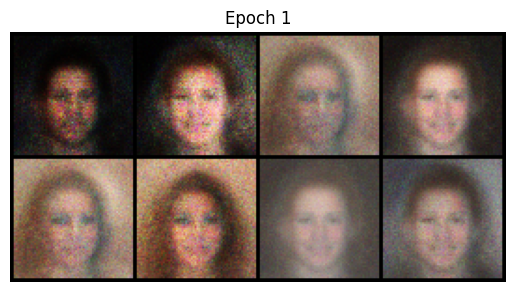

Epoch: 2/5 Batch: 1 G_loss: 2.8118 D_loss: 0.2193
Epoch: 2/5 Batch: 51 G_loss: 4.4279 D_loss: 0.3652
Epoch: 2/5 Batch: 101 G_loss: 4.4733 D_loss: 0.2759
Epoch: 2/5 Batch: 151 G_loss: 4.6290 D_loss: 0.2342
Epoch: 2/5 Batch: 201 G_loss: 2.9372 D_loss: 0.3571
Epoch: 2/5 Batch: 251 G_loss: 2.8460 D_loss: 0.2463
Epoch: 2/5 Batch: 301 G_loss: 2.3191 D_loss: 0.4651
Epoch: 2/5 Batch: 351 G_loss: 1.7532 D_loss: 0.3791
Epoch: 2/5 Batch: 401 G_loss: 3.2349 D_loss: 0.3592
Epoch: 2/5 Batch: 451 G_loss: 2.7397 D_loss: 0.1837
Epoch: 2/5 Batch: 501 G_loss: 3.8104 D_loss: 0.3171
Epoch: 2/5 Batch: 551 G_loss: 2.8839 D_loss: 0.2069
Epoch: 2/5 Batch: 601 G_loss: 3.4582 D_loss: 0.2903
Epoch: 2/5 Batch: 651 G_loss: 2.6638 D_loss: 0.3012
Epoch: 2/5 Batch: 701 G_loss: 2.5033 D_loss: 0.4486
Epoch: 2/5 Batch: 751 G_loss: 2.5791 D_loss: 0.3819
Epoch: 2/5 Batch: 801 G_loss: 2.9163 D_loss: 0.2394
Epoch: 2/5 Batch: 851 G_loss: 2.9879 D_loss: 0.2763
Epoch: 2/5 Batch: 901 G_loss: 3.1316 D_loss: 0.2506
Epoch: 2/5 Batc

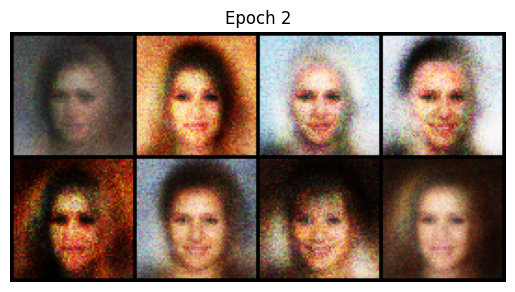

Epoch: 3/5 Batch: 1 G_loss: 2.1871 D_loss: 0.3657
Epoch: 3/5 Batch: 51 G_loss: 2.7861 D_loss: 0.3020
Epoch: 3/5 Batch: 101 G_loss: 2.4919 D_loss: 0.3748
Epoch: 3/5 Batch: 151 G_loss: 2.1006 D_loss: 0.4255
Epoch: 3/5 Batch: 201 G_loss: 3.0587 D_loss: 0.2720
Epoch: 3/5 Batch: 251 G_loss: 2.5126 D_loss: 0.3874
Epoch: 3/5 Batch: 301 G_loss: 2.2222 D_loss: 0.3641
Epoch: 3/5 Batch: 351 G_loss: 2.0846 D_loss: 0.4871
Epoch: 3/5 Batch: 401 G_loss: 2.3020 D_loss: 0.4216
Epoch: 3/5 Batch: 451 G_loss: 2.4496 D_loss: 0.3314
Epoch: 3/5 Batch: 501 G_loss: 2.1171 D_loss: 0.3549
Epoch: 3/5 Batch: 551 G_loss: 3.1543 D_loss: 0.2795
Epoch: 3/5 Batch: 601 G_loss: 2.3734 D_loss: 0.3871
Epoch: 3/5 Batch: 651 G_loss: 2.4006 D_loss: 0.3014
Epoch: 3/5 Batch: 701 G_loss: 2.4655 D_loss: 0.3816
Epoch: 3/5 Batch: 751 G_loss: 2.8903 D_loss: 0.4228
Epoch: 3/5 Batch: 801 G_loss: 2.4415 D_loss: 0.4405
Epoch: 3/5 Batch: 851 G_loss: 2.3945 D_loss: 0.3101
Epoch: 3/5 Batch: 901 G_loss: 2.2965 D_loss: 0.3486
Epoch: 3/5 Batc

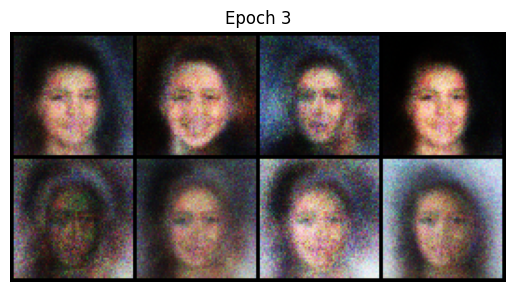

Epoch: 4/5 Batch: 1 G_loss: 2.2862 D_loss: 0.4468
Epoch: 4/5 Batch: 51 G_loss: 1.8116 D_loss: 0.4607
Epoch: 4/5 Batch: 101 G_loss: 3.6469 D_loss: 0.6346
Epoch: 4/5 Batch: 151 G_loss: 1.8745 D_loss: 0.5238
Epoch: 4/5 Batch: 201 G_loss: 1.5130 D_loss: 0.5549
Epoch: 4/5 Batch: 251 G_loss: 2.2842 D_loss: 0.3955
Epoch: 4/5 Batch: 301 G_loss: 1.9765 D_loss: 0.4500
Epoch: 4/5 Batch: 351 G_loss: 2.0475 D_loss: 0.3621
Epoch: 4/5 Batch: 401 G_loss: 2.0266 D_loss: 0.4430
Epoch: 4/5 Batch: 451 G_loss: 1.7687 D_loss: 0.5718
Epoch: 4/5 Batch: 501 G_loss: 2.4768 D_loss: 0.5866
Epoch: 4/5 Batch: 551 G_loss: 2.0280 D_loss: 0.5039
Epoch: 4/5 Batch: 601 G_loss: 3.4956 D_loss: 0.5468
Epoch: 4/5 Batch: 651 G_loss: 1.6698 D_loss: 0.5591
Epoch: 4/5 Batch: 701 G_loss: 2.0601 D_loss: 0.4247
Epoch: 4/5 Batch: 751 G_loss: 2.2069 D_loss: 0.4252
Epoch: 4/5 Batch: 801 G_loss: 1.7904 D_loss: 0.5934
Epoch: 4/5 Batch: 851 G_loss: 1.9941 D_loss: 0.4121
Epoch: 4/5 Batch: 901 G_loss: 2.1342 D_loss: 0.5016
Epoch: 4/5 Batc

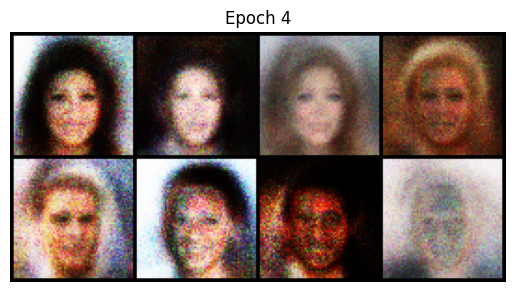

Epoch: 5/5 Batch: 1 G_loss: 2.4750 D_loss: 0.4110
Epoch: 5/5 Batch: 51 G_loss: 2.5755 D_loss: 0.3341
Epoch: 5/5 Batch: 101 G_loss: 2.0482 D_loss: 0.4498
Epoch: 5/5 Batch: 151 G_loss: 1.9537 D_loss: 0.5417
Epoch: 5/5 Batch: 201 G_loss: 2.1363 D_loss: 0.3665
Epoch: 5/5 Batch: 251 G_loss: 1.9878 D_loss: 0.4183
Epoch: 5/5 Batch: 301 G_loss: 1.8793 D_loss: 0.4524
Epoch: 5/5 Batch: 351 G_loss: 1.9973 D_loss: 0.4358
Epoch: 5/5 Batch: 401 G_loss: 2.1084 D_loss: 0.4764
Epoch: 5/5 Batch: 451 G_loss: 1.9789 D_loss: 0.4008
Epoch: 5/5 Batch: 501 G_loss: 2.0922 D_loss: 0.4725
Epoch: 5/5 Batch: 551 G_loss: 2.1668 D_loss: 0.4805
Epoch: 5/5 Batch: 601 G_loss: 1.8113 D_loss: 0.5460
Epoch: 5/5 Batch: 651 G_loss: 2.1986 D_loss: 0.4363
Epoch: 5/5 Batch: 701 G_loss: 1.8383 D_loss: 0.4688
Epoch: 5/5 Batch: 751 G_loss: 2.0717 D_loss: 0.5062
Epoch: 5/5 Batch: 801 G_loss: 1.6160 D_loss: 0.5377
Epoch: 5/5 Batch: 851 G_loss: 1.7130 D_loss: 0.4256
Epoch: 5/5 Batch: 901 G_loss: 1.6223 D_loss: 0.5568
Epoch: 5/5 Batc

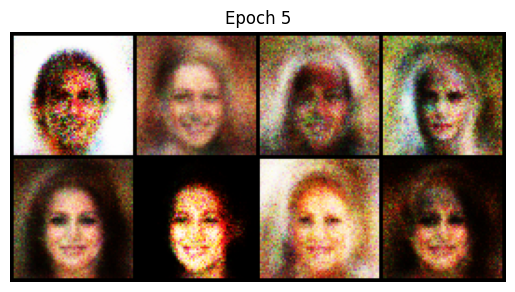

In [77]:
train(generator, discriminator, dataloader, epochs=5)